C:\Users\admin\AppData\Local\Temp\ipykernel_3224\1634169465.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=train_df, palette='magma')


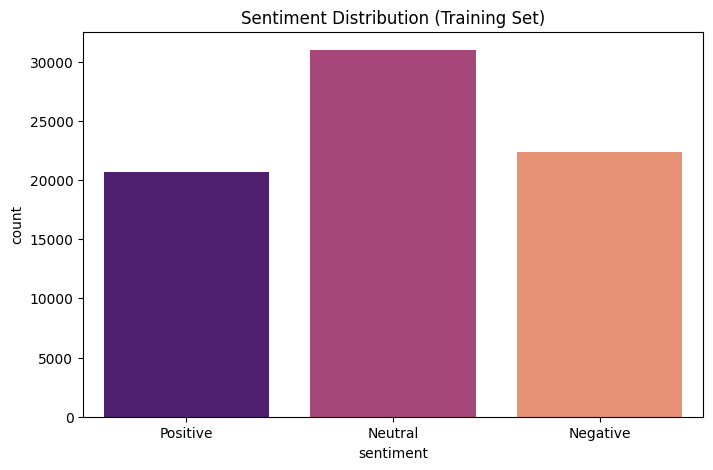

Overall Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82       266
     Neutral       0.84      0.82      0.83       457
    Positive       0.82      0.79      0.80       277

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



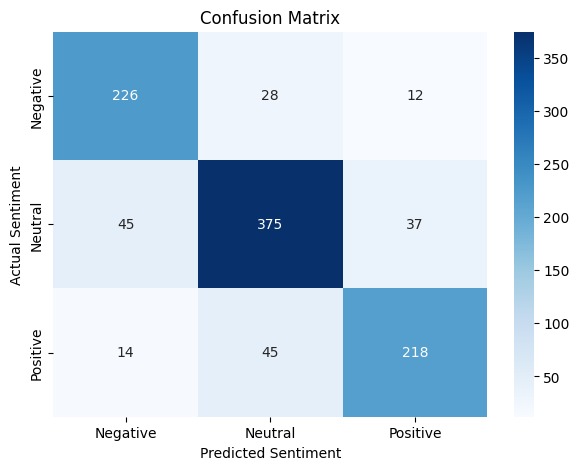

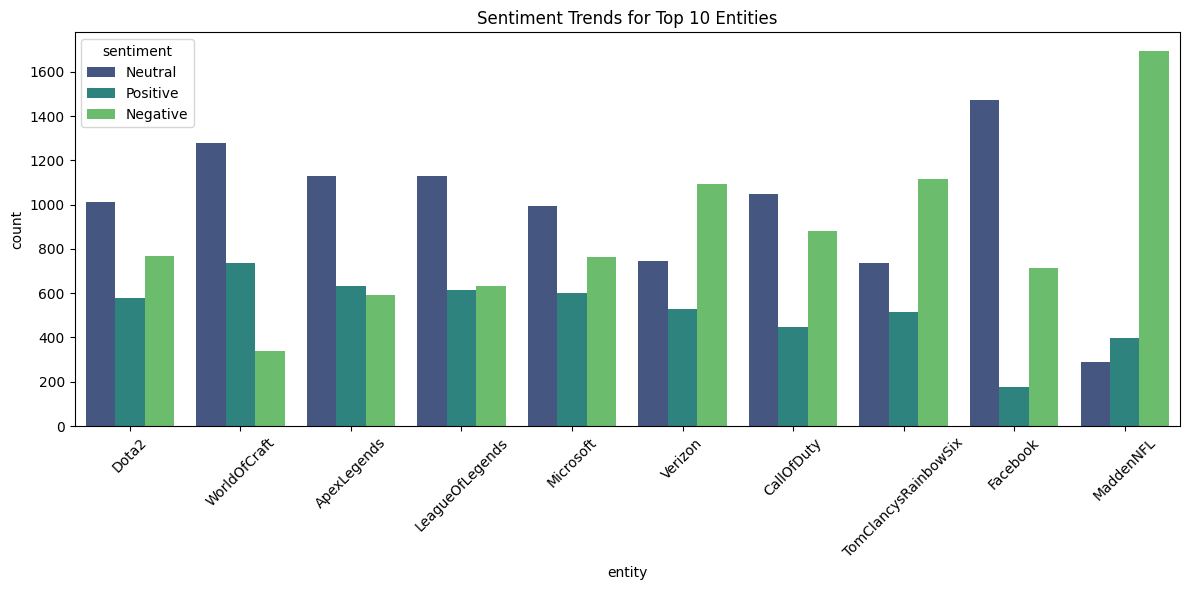

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. Load the Datasets
# ---------------------------------------------------------
column_names = ['id', 'entity', 'sentiment', 'text']
train_df = pd.read_csv('twitter_training.csv', names=column_names)
valid_df = pd.read_csv('twitter_validation.csv', names=column_names)

# ---------------------------------------------------------
# 2. Data Preprocessing
# ---------------------------------------------------------
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'\@\w+|\#','', text)                  # Remove mentions and hashtags
    text = re.sub(r'[^\w\s]', '', text)                  # Remove punctuation
    return text.strip()

# Map 'Irrelevant' to 'Neutral' as per task requirements
train_df['sentiment'] = train_df['sentiment'].replace('Irrelevant', 'Neutral')
valid_df['sentiment'] = valid_df['sentiment'].replace('Irrelevant', 'Neutral')

# Drop missing values
train_df.dropna(subset=['text'], inplace=True)
valid_df.dropna(subset=['text'], inplace=True)

# Apply text cleaning
train_df['clean_text'] = train_df['text'].apply(clean_text)
valid_df['clean_text'] = valid_df['text'].apply(clean_text)

# ---------------------------------------------------------
# 3. Exploratory Data Analysis (EDA)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=train_df, palette='magma')
plt.title('Sentiment Distribution (Training Set)')
plt.show()

# ---------------------------------------------------------
# 4. Feature Extraction (TF-IDF)
# ---------------------------------------------------------
# We use TF-IDF to convert text into numerical vectors
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(train_df['clean_text'])
X_test = tfidf.transform(valid_df['clean_text'])

y_train = train_df['sentiment']
y_test = valid_df['sentiment']

# ---------------------------------------------------------
# 5. Model Training (Logistic Regression)
# ---------------------------------------------------------
# Logistic Regression is excellent for high-dimensional text data
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 6. Evaluation
# ---------------------------------------------------------
y_pred = model.predict(X_test)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix')
plt.show()

# ---------------------------------------------------------
# 7. Entity Sentiment Insight
# ---------------------------------------------------------
# Check how sentiment varies across specific entities (e.g., Google, Microsoft)
top_entities = train_df['entity'].value_counts().head(10).index
subset = train_df[train_df['entity'].isin(top_entities)]

plt.figure(figsize=(12, 6))
sns.countplot(data=subset, x='entity', hue='sentiment', palette='viridis')
plt.title('Sentiment Trends for Top 10 Entities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()